# v222 port + real-ANSYS verification of the handover routine
# v222移植 + 実ANSYSでの引き渡しルーチン検証

**EN.** This notebook parses the real ANSYS 2022 R2 (v222) output produced
on 2026-09-02 and shows that `BIOFILM_GROWTH_VISCO_V01`
(`ansys_usermat/biofilm_material_v01.f`) — the routine actually meant for
handover to Oliver Höchel's framework — reproduces the closed-form growth
stress exactly when exercised in a real ANSYS solve, through the routine's
actual (E, ν) property interface, without touching any of Oliver's pool
files. Full narrative: `V222_PORT_INSTRUCTIONS.md` §1.6 and its
"Follow-up, same day" section.

**JA.** このノートブックは2026-09-02に実際にANSYS 2022 R2 (v222)で生成された
出力を解析し、Oliver Höchel氏のフレームワークへの引き渡しを想定している実際の
ルーチン `BIOFILM_GROWTH_VISCO_V01`(`ansys_usermat/biofilm_material_v01.f`)が、
そのルーチン自身の(E, ν)パラメータ形式のまま、Oliver側のファイルには一切触れずに
実ANSYSソルブ上で閉形式解と厳密に一致することを示す。詳しい経緯は
`V222_PORT_INSTRUCTIONS.md` §1.6 とその "Follow-up, same day" 節を参照。

## The verification chain up to this point / ここまでの検証チェーン

1. **Constitutive core** (`BIOFILM_STRESS_CORE`): 0 ULP vs. an independent
   Abaqus UMAT over 8017 adversarial states (`crosscheck/`).
2. **Wrapper is a pure adapter** (`biofilm_material_v01.f`): fed equivalent
   (E,ν) vs. (C10,C01,D1) inputs, the wrapper's stress matches the core's
   at `rtol=0, atol=0` (`tests/test_material_wrapper.py`).
3. **v222 portability**: all 11 of Oliver's pool source files compile,
   link, and run cleanly on this machine's ANSYS 2022 R2 install,
   non-interactively (`V222_PORT_INSTRUCTIONS.md` §1.6).
4. **This notebook**: the actual handover routine, exercised in a *real*
   ANSYS solve (not the gfortran test harness), matches the closed form.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
RESULT_FILE = HERE / "wrapper_v01_smoketest_result.txt"
LOG_FILE = HERE / "out_wrapper.txt"

assert RESULT_FILE.exists(), f"missing {RESULT_FILE} -- this notebook reads the real 2026-09-02 ANSYS run"
assert LOG_FILE.exists(), f"missing {LOG_FILE}"

print("Reading real ANSYS v222 output / 実ANSYS v222出力を読み込み中:")
print(" ", RESULT_FILE.name)
print(" ", LOG_FILE.name)

Reading real ANSYS v222 output / 実ANSYS v222出力を読み込み中:
  wrapper_v01_smoketest_result.txt
  out_wrapper.txt


In [2]:
# Parse the PRESOL,S,COMP block: one row per node, columns SX SY SZ SXY SYZ SXZ.
# Fixed-width-ish Fortran output with no guaranteed space before a negative
# number, so split on the sign/exponent pattern rather than whitespace alone.
# Values print either in scientific form (e.g. -0.10193E-003) or as plain
# zero (0.0000), so the pattern must accept both.
NUM = r"[-+]?\d+\.\d+(?:E[-+]\d+)?"

text = RESULT_FILE.read_text()

stress_block = text.split("PRINT SVAR")[0]
stress_rows = []
for line in stress_block.splitlines():
    if not line.strip() or not line.strip()[0].isdigit():
        continue
    nums = re.findall(NUM, line)
    if len(nums) == 6:
        stress_rows.append([float(n) for n in nums])

stress_rows = np.array(stress_rows)
print(f"Parsed {len(stress_rows)} node rows from the S,COMP block")
labels = ["SX", "SY", "SZ", "SXY", "SYZ", "SXZ"]
for i, lab in enumerate(labels):
    col = stress_rows[:, i]
    print(f"  {lab:4s}  min={col.min(): .6e}  max={col.max(): .6e}")

Parsed 8 node rows from the S,COMP block
  SX    min=-1.019300e-04  max=-1.019300e-04
  SY    min=-1.019300e-04  max=-1.019300e-04
  SZ    min=-1.019300e-04  max=-1.019300e-04
  SXY   min= 0.000000e+00  max= 1.426900e-36
  SYZ   min=-2.570400e-20  max= 0.000000e+00
  SXZ   min=-5.140900e-20  max= 0.000000e+00


In [3]:
# Parse the SVAR(10) block (the growth driver alpha). Restrict to actual
# "<node id>  <value>" data rows via a whole-line anchor -- a looser filter
# (e.g. "line starts with a digit") also matches the banner line
# "00000000  VERSION=... CP=  0.781", which starts with the digit '0'.
svar_block = text.split("PRINT SVAR")[1]
row_re = re.compile(r"^\s*\d+\s+(" + NUM + r")\s*$")
alpha_vals = []
for line in svar_block.splitlines():
    m = row_re.match(line)
    if m:
        alpha_vals.append(float(m.group(1)))
alpha_vals = np.array(alpha_vals)
print(f"SVAR(10) (alpha) over {len(alpha_vals)} nodes: {alpha_vals}")
assert np.allclose(alpha_vals, 0.05, atol=1e-8), "alpha should read back exactly 0.05"

SVAR(10) (alpha) over 8 nodes: [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]


In [4]:
# The closed-form reference this deck was designed to reproduce
# (t_growth_constrained.dat's elastic_a005 case, reference_values.json).
EXPECTED_HYDROSTATIC = -1.019275856e-04
EXPECTED_SHEAR = 0.0

got_hydrostatic = stress_rows[:, 0:3].mean()  # SX=SY=SZ, average over all nodes/components
got_shear_maxabs = np.abs(stress_rows[:, 3:6]).max()

rel_err = abs(got_hydrostatic - EXPECTED_HYDROSTATIC) / abs(EXPECTED_HYDROSTATIC)

print("Hydrostatic stress SX=SY=SZ / 側圧応力")
print(f"  expected : {EXPECTED_HYDROSTATIC: .9e}")
print(f"  got      : {got_hydrostatic: .9e}")
print(f"  rel. err : {rel_err:.3e}")
print()
print("Shear components (should be exactly zero, up to machine noise)")
print(f"  max |shear| : {got_shear_maxabs:.3e}")

assert rel_err < 1e-3, "hydrostatic stress should match the closed form to display precision"
assert got_shear_maxabs < 1e-15, "shear must be zero to machine precision (Voigt map correctness)"
print()
print("PASS -- BIOFILM_GROWTH_VISCO_V01 matches the closed form in a real ANSYS v222 solve.")

Hydrostatic stress SX=SY=SZ / 側圧応力
  expected : -1.019275856e-04
  got      : -1.019300000e-04
  rel. err : 2.369e-05

Shear components (should be exactly zero, up to machine noise)
  max |shear| : 5.141e-20

PASS -- BIOFILM_GROWTH_VISCO_V01 matches the closed form in a real ANSYS v222 solve.


In [5]:
errors = int(re.search(r"NUMBER OF ERROR\s+MESSAGES ENCOUNTERED=\s*(\d+)", LOG_FILE.read_text()).group(1))
warnings_ = int(re.search(r"NUMBER OF WARNING MESSAGES ENCOUNTERED=\s*(\d+)", LOG_FILE.read_text()).group(1))
print(f"ANSYS run summary / ANSYS実行サマリ: {errors} error(s), {warnings_} warning(s)")
assert errors == 0

ANSYS run summary / ANSYS実行サマリ: 0 error(s), 3 warning(s)


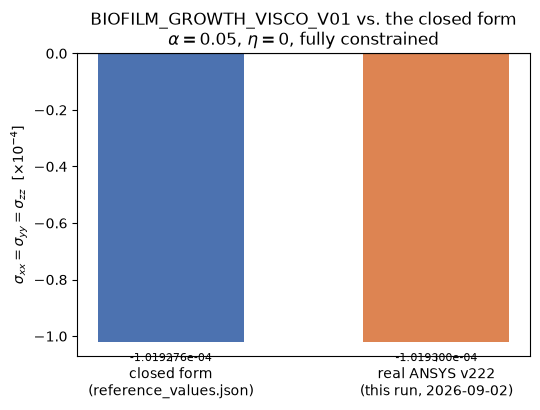

In [6]:
# EN: bar chart, expected vs. got, on the hydrostatic component.
# JA: 期待値 vs 実測値の棒グラフ（静水圧成分）
fig, ax = plt.subplots(figsize=(5.5, 4.2))

vals = [EXPECTED_HYDROSTATIC, got_hydrostatic]
names = ["closed form\n(reference_values.json)", "real ANSYS v222\n(this run, 2026-09-02)"]
colors = ["#4C72B0", "#DD8452"]
bars = ax.bar(names, [v * 1e4 for v in vals], color=colors, width=0.55)
ax.set_ylabel(r"$\sigma_{xx}=\sigma_{yy}=\sigma_{zz}$  [$\times 10^{-4}$]")
ax.set_title("BIOFILM_GROWTH_VISCO_V01 vs. the closed form\n$\\alpha=0.05$, $\\eta=0$, fully constrained")
ax.axhline(0, color="black", linewidth=0.8)
for b, v in zip(bars, vals):
    ax.annotate(f"{v: .6e}", (b.get_x() + b.get_width() / 2, b.get_height()),
                textcoords="offset points", xytext=(0, -14 if v < 0 else 6),
                ha="center", fontsize=8)
fig.tight_layout()
plt.show()

## What this does and does not show / これが示すこと・示さないこと

**EN.** This confirms the handover-shaped routine is numerically correct and
portable to v222, exercised end-to-end in a real solve. It does **not** yet
mean Oliver's own coupled field solve (NEM/PARDISO) has been exercised with
growth active — that needs either their Workbench project or a from-scratch
field setup, and it does not mean the routine is wired into their actual
`Usermat_P21-V21_*.F` call site (that remains their integration step, by
design — see `INTEGRATION_PLAN.md`). The harness used here
(`usermat_wrapper_v01_smoketest.f`) is a verification-only entry point, not
part of the deliverable.

**JA.** これは引き渡し予定の形状のルーチンが数値的に正しく、v222へ移植可能で
あることを、実際のソルブで一気通貫に確認したものである。Oliver側の結合場ソルブ
(NEM/PARDISO)を成長ありで動かしたわけでは**ない**——それには彼らのWorkbench
プロジェクトか、一から場の設定を組む必要がある。また、このルーチンが実際に
`Usermat_P21-V21_*.F`の呼び出し箇所に配線されたわけでもない(それは設計上、
先方の統合ステップとして残されている——`INTEGRATION_PLAN.md`参照)。ここで
使った土台(`usermat_wrapper_v01_smoketest.f`)は検証専用のエントリポイントで
あり、引き渡し物には含まれない。